In [1]:
import pandas as pd
from prophet import Prophet
import numpy as np

c:\Users\egorl\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_excel("Данные по регионам\\region 0.xlsx", index_col=False)


In [3]:
df.columns = ['ds', 'y', 'temperature 0', 'day type']

In [18]:
train = df[:1825]
test = df[1825:]

In [16]:
model = Prophet()
model.add_regressor('temperature 0')
model.add_regressor('day type')

In [17]:
model.fit(train)

21:19:31 - cmdstanpy - INFO - Chain [1] start processing
21:19:32 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse

In [29]:
rmses = []
maes = []
predictions = []
lower_bounds = []
upper_bounds = []

c = 1825
for i in range(0, len(df[1825:]), 7):

    predicts = []
    confs = []

    for j in range(i, i+7):

        future = model.make_future_dataframe(periods=7 + j)
        future["temperature 0"] = df["temperature 0"][:c + 7 + j]
        future["day type"] = df["day type"][:c + 7 + j]

        forecast = model.predict(future)
        yhat = np.array(forecast["yhat"])[-7:]

        predicts.append(yhat)
        confs.append(np.array(forecast[["yhat_lower", "yhat_upper"]])[-7:])

        rmses.append(np.sqrt(mse(yhat, df["y"][c + j:c + 7 + j])))
        maes.append(mae(yhat, df["y"][c + j:c + 7 + j]))

    predictions.append(predicts[0])

    for k in confs[0]:
        lower_bounds.append(k[0])
        upper_bounds.append(k[1])

    model = Prophet()
    model.add_regressor('temperature 0')
    model.add_regressor('day type')

    model.fit(df[:1825 + i + 7])

    c = c + 7

    

    

21:29:01 - cmdstanpy - INFO - Chain [1] start processing
21:29:01 - cmdstanpy - INFO - Chain [1] done processing
21:29:03 - cmdstanpy - INFO - Chain [1] start processing
21:29:03 - cmdstanpy - INFO - Chain [1] done processing
21:29:05 - cmdstanpy - INFO - Chain [1] start processing
21:29:06 - cmdstanpy - INFO - Chain [1] done processing
21:29:08 - cmdstanpy - INFO - Chain [1] start processing
21:29:08 - cmdstanpy - INFO - Chain [1] done processing
21:29:10 - cmdstanpy - INFO - Chain [1] start processing
21:29:10 - cmdstanpy - INFO - Chain [1] done processing
21:29:12 - cmdstanpy - INFO - Chain [1] start processing
21:29:12 - cmdstanpy - INFO - Chain [1] done processing
21:29:15 - cmdstanpy - INFO - Chain [1] start processing
21:29:15 - cmdstanpy - INFO - Chain [1] done processing
21:29:17 - cmdstanpy - INFO - Chain [1] start processing
21:29:18 - cmdstanpy - INFO - Chain [1] done processing
21:29:20 - cmdstanpy - INFO - Chain [1] start processing
21:29:20 - cmdstanpy - INFO - Chain [1]

ValueError: Found NaN in column 'temperature 0'

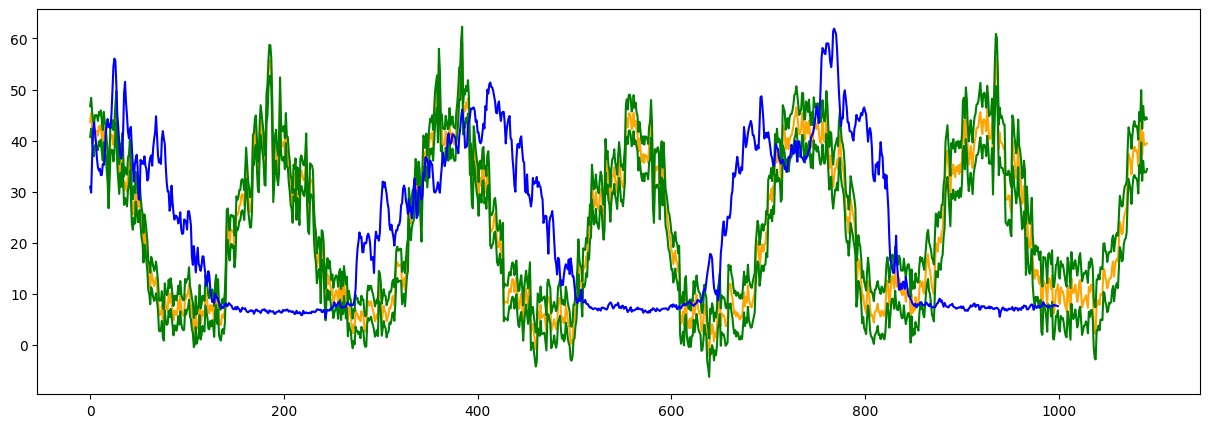

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(predictions[:2000], color="orange", label='predicted values')
#plt.plot(np.array(df["y"])[1825:1800+200], color="blue", label='true values')
plt.plot(lower_bounds[:2000], color="green", label='lower bound values')
plt.plot(upper_bounds[:2000], color="green", label='upper bound values')
plt.plot(df["y"][:1000], color="blue")
plt.show()

In [32]:
predictions = np.array(predictions).flatten()

In [44]:
np.std(np.array(rmses))

1.2236256027444827

In [14]:
test["temperature_0"][:7]

850    21.0
851    22.0
852    23.0
853    22.0
854    22.0
855    23.0
856    21.0
Name: temperature_0, dtype: float64

In [8]:
future = model.make_future_dataframe(periods=7)
future["temperature 0"] = df["temperature 0"][:1832]
future["day type"] = df["day type"][:1832]


In [9]:
forecast=model.predict(future)

In [14]:
forecast[["yhat", "yhat_upper", "yhat_lower"]]

,yhat,yhat_upper,yhat_lower
0,34.112563,37.133348,31.275666
1,31.537478,34.633930,28.768927
2,34.956013,37.685982,32.021462
3,41.188632,44.052452,38.516289
4,45.576087,48.684873,42.581210
...,...,...,...
1827,42.653058,45.763553,39.640635
1828,40.954409,43.869739,37.926810
1829,40.034058,42.928728,37.076513
1830,41.928077,44.971037,38.755907


In [39]:
from sklearn.metrics import mean_squared_error as mse
mse(forecast["yhat"][-7:], df["y"][850:857])

3.228196486585862

In [109]:
model.fit(merged_data)

23:31:40 - cmdstanpy - INFO - Chain [1] start processing
23:31:41 - cmdstanpy - INFO - Chain [1] done processing


In [125]:
train

,ds,y,temperature_0,id
0,2010-01-01,30.972282,7.0,3
1,2010-01-02,29.846362,10.0,3
2,2010-01-03,36.359652,6.0,3
3,2010-01-04,41.859071,-1.0,3
4,2010-01-05,43.567304,-6.0,3
...,...,...,...,...
2808,2017-09-09,7.878640,23.0,1
2809,2017-09-10,7.459769,24.0,1
2810,2017-09-11,7.407515,25.0,0
2811,2017-09-12,7.458709,28.0,0


In [128]:
future = model.make_future_dataframe(periods=7)
future["temperature_0"] = merged_data["temperature_0"][:int(merged_data.shape[0]*0.7)+8]
future["id"] = merged_data["id"][:int(merged_data.shape[0]*0.7)+8]

In [130]:
forecast = model.predict(future)


In [131]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7))

             ds      yhat  yhat_lower  yhat_upper
2813 2017-09-14  6.044654    3.241352    8.999145
2814 2017-09-15  5.162703    2.227599    8.066162
2815 2017-09-16  6.012444    2.888883    8.597296
2816 2017-09-17  4.225996    1.311265    7.188534
2817 2017-09-18  5.286957    2.331956    8.140883
2818 2017-09-19  3.570692    0.567235    6.610412
2819 2017-09-20  2.733123   -0.351980    5.643660
